# Apex Asset Management — Senior Data Analyst Case Study

**Analyst:** Candidate Submission | **As-of date:** 31 May 2026 | **Deadline:** 20 June 2026

This notebook is **fully self-contained**. It reads directly from the raw Excel sources
and follows a strict layered pipeline:

`ingest → profile → clean & validate → canonical dataset → analysis`

Analysis never touches raw data, and **no constant names a fund or a status before that
value has been discovered in the data and validated by assertion.** Presentation constants
(colours, labels, chart style) are derived from the validated domain and defined only once
analysis begins.

---


## Section 1 — Environment Setup

In [ ]:
import warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from lifelines import KaplanMeierFitter

# ── Paths ───────────────────────────────────
REPO        = Path("..").resolve()
CORE_PATH   = REPO / "raw" / "Apex_Core_Database.xlsx"
LEDGER_PATH = REPO / "raw" / "Apex_Transaction_Ledger.xlsx"

AS_OF = pd.Timestamp("2026-05-31")
SEED  = 42

# Source-system placeholder strings. Content-neutral: this asserts nothing about
# which funds or statuses exist, only which tokens stand in for "no value".
SENTINELS = {" ", "", "00:00:00", "1900-01-01"}

def taka(v, cr=False):
    if cr:
        return f"৳{v/1e7:.1f} Cr"
    if abs(v) >= 1e7:
        return f"৳{v/1e7:.2f} Cr"
    if abs(v) >= 1e5:
        return f"৳{v/1e5:.1f} L"
    return f"৳{v:,.0f}"

print("Environment ready. AS_OF =", AS_OF.date())


Environment ready. AS_OF = 2026-05-31


## Section 2 — Data Ingestion & Type Audit

In [2]:
# ── 2.1 Master File ──────────────────────────────────────────
raw_master = pd.read_excel(CORE_PATH, sheet_name="Master File", dtype=str)
print(f"Master File: {raw_master.shape[0]:,} rows × {raw_master.shape[1]} columns")
print(raw_master.dtypes.to_string())


Master File: 12,229 rows × 21 columns
Registration No                 object
Fund                            object
Investment Type                 object
Customer No.                    object
Activity Status                 object
Mobile No                       object
Customer Name                   object
Age                             object
Amount (While onboarding)       object
Current Installment Amount      object
Tenor In Month                  object
First Purchase Date             object
Tenure Maturity Date            object
Service RM Name                 object
Service RM CIF                  object
Onboarding Department           object
Introducer RM Name              object
Introducer RM CIF               object
Investment Value (At Market)    object
Account Closing Date            object
SIP Discontinuation Date        object


In [3]:
# ── 2.2 RM List ──────────────────────────────────────────────
# Column A is empty; header 'Introducer RM Name' is in B1; names in B2:B17
rmlist_raw = pd.read_excel(CORE_PATH, sheet_name="RM List", header=None, usecols=[1])
OFFICIAL_RM_NAMES = set(rmlist_raw.iloc[1:, 0].dropna().astype(str).str.strip())
print(f"Official RM list: {len(OFFICIAL_RM_NAMES)} names")
for n in sorted(OFFICIAL_RM_NAMES):
    print(" ", n)


Official RM list: 16 names
  CHAMPA DEY
  JANNATUL ISLAM
  JASIM FARUKI
  KAZI JALAL RANA
  MOHAMMAD JASIM AHMED
  MOST. KAMRUN MIA
  MOST. SAFURA MIA
  MOST. SUMAYA SIDDIQUE
  MST. RINA AKTER
  MST. SHANTA SHEIKH
  MST. SHARMIN BHUIYAN
  MST. SONIA SHEIKH
  MUNIRA BEGUM
  SHARIFA BEGUM
  SHIBANI DATTA
  UMME LINA SIDDIQUE


In [4]:
# ── 2.3 Transaction Ledger ───────────────────────────────────
raw_ledger = pd.read_excel(LEDGER_PATH, sheet_name="Transection", dtype=str)
print(f"Ledger ('Transection'): {raw_ledger.shape[0]:,} rows × {raw_ledger.shape[1]} columns")
print(raw_ledger.dtypes.to_string())


Ledger ('Transection'): 231,254 rows × 5 columns
Account Number             object
Customer Name              object
Type of Transaction        object
Total                      object
Purchase/Surrender Date    object


In [5]:
# ── 2.4 Unique transaction types ─────────────────────────────
print("Transaction types:", raw_ledger["Type of Transaction"].value_counts().to_dict())


Transaction types: {'Purchase': 209675, 'Dividend': 13524, 'Surrender': 8055}


## Section 3 — Data Profiling (Domain Discovery)

Before defining **any** constant that names a fund or a status, we enumerate what
actually exists in the raw data. Every domain constant used later — the status
mapping, the churn categories, and the fund colour/label maps — is *derived from
and validated against* the values discovered here, never assumed ahead of evidence.

This is the step that answers “how do we know these funds/statuses exist?” — we look first.


In [6]:
# ── 3.1 Enumerate the categorical domain ─────────────
print("Distinct Fund values:")
print(raw_master["Fund"].value_counts(dropna=False).to_string())

print("\nDistinct Activity Status values:")
print(raw_master["Activity Status"].value_counts(dropna=False).to_string())

print("\nDistinct Investment Type values:")
print(raw_master["Investment Type"].value_counts(dropna=False).to_string())

# Capture the observed domains as the single source of truth for everything downstream.
OBSERVED_FUNDS    = sorted(raw_master["Fund"].dropna().str.strip().unique())
OBSERVED_STATUSES = sorted(raw_master["Activity Status"].dropna().str.strip().unique())
print(f"\n{len(OBSERVED_FUNDS)} funds discovered:   ", OBSERVED_FUNDS)
print(f"{len(OBSERVED_STATUSES)} statuses discovered:", OBSERVED_STATUSES)


Distinct Fund values:
Fund
Apex Capital Growth Fund          3779
Apex Fixed Income Fund            3221
Apex Shariah Growth Fund          3086
Apex Balanced Opportunity Fund    2143

Distinct Activity Status values:
Activity Status
Active         6925
Closed         3500
Inactive       1124
Discontinue     678
Suspended         2

Distinct Investment Type values:
Investment Type
SIP        10428
NON SIP     1801

4 funds discovered:    ['Apex Balanced Opportunity Fund', 'Apex Capital Growth Fund', 'Apex Fixed Income Fund', 'Apex Shariah Growth Fund']
5 statuses discovered: ['Active', 'Closed', 'Discontinue', 'Inactive', 'Suspended']


## Section 4 — Missing Value Audit

In [7]:
def null_audit(df, label=""):
    n = len(df)
    s = df.isnull().sum()
    pct = (s / n * 100).round(1)
    out = pd.DataFrame({"nulls": s, "pct": pct})
    out = out[out["nulls"] > 0].sort_values("nulls", ascending=False)
    print(f"\n=== Null audit: {label} ({n:,} rows) ===")
    print(out.to_string())
    return out

master_nulls = null_audit(raw_master, "Master File")
ledger_nulls = null_audit(raw_ledger, "Ledger")



=== Null audit: Master File (12,229 rows) ===
                          nulls   pct
Introducer RM CIF          1983  16.2
Onboarding Department      1983  16.2
Age                          57   0.5
Service RM CIF                9   0.1
Account Closing Date          2   0.0
SIP Discontinuation Date      1   0.0

=== Null audit: Ledger (231,254 rows) ===
Empty DataFrame
Columns: [nulls, pct]
Index: []


> ### 📊 Business Insight
>
> **Missing event dates are structurally expected — not random data quality failures.**
>
> `Account Closing Date` and `SIP Discontinuation Date` are only populated when a
> closure or discontinuation event occurs. The large null counts for these columns
> reflect the share of accounts that are still active, **not** missing data entry.
> Age is missing for a small fraction of accounts; we flag but retain these rows.
>
> **Why it matters:** Treating event-date nulls as errors would incorrectly drop
> thousands of valid active accounts from survival and retention analyses.


## Section 5 — Anomaly Detection

In [8]:
# ── 4.1 Sentinel values in date / amount columns ─────────────
DATE_COLS   = ["First Purchase Date", "Tenure Maturity Date",
               "Account Closing Date", "SIP Discontinuation Date"]
AMOUNT_COLS = ["Amount (While onboarding)", "Current Installment Amount",
               "Tenor In Month", "Investment Value (At Market)"]

def sentinel_count(df, cols):
    results = {}
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c].astype(str).str.strip()
        mask = s.isin(SENTINELS) | s.str.startswith("1900-01-01")
        results[c] = int(mask.sum())
    return pd.Series(results, name="sentinel_count").sort_values(ascending=False)

print("Sentinel hits — date columns:")
print(sentinel_count(raw_master, DATE_COLS).to_string())
print("\nSentinel hits — numeric columns:")
print(sentinel_count(raw_master, AMOUNT_COLS).to_string())


Sentinel hits — date columns:
SIP Discontinuation Date    11551
Account Closing Date         8730
Tenure Maturity Date         1801
First Purchase Date             0

Sentinel hits — numeric columns:
Amount (While onboarding)       0
Current Installment Amount      0
Tenor In Month                  0
Investment Value (At Market)    0


In [9]:
# ── 4.2 RM List sheet anomaly ────────────────────────────────
col_a = pd.read_excel(CORE_PATH, sheet_name="RM List", header=None, usecols=[0])
print("Column A of RM List (should be empty):")
print(col_a.head(5))
print(f"Non-null values in col A: {col_a.iloc[:,0].notna().sum()}")
print("\n=> RM names live in column B, not column A — loaded via usecols=[1].")


Column A of RM List (should be empty):
    0
0 NaN
1 NaN
2 NaN
3 NaN
4 NaN
Non-null values in col A: 0

=> RM names live in column B, not column A — loaded via usecols=[1].


In [10]:
# ── 4.3 Age flags ────────────────────────────────────────────
ages_raw = pd.to_numeric(raw_master["Age"], errors="coerce")
too_young = (ages_raw < 18).sum()
too_old   = (ages_raw > 100).sum()
missing   = ages_raw.isna().sum()
print(f"Age < 18:   {too_young}")
print(f"Age > 100:  {too_old}")
print(f"Age missing:{missing}")
print(f"Valid ages: {len(ages_raw) - too_young - too_old - missing:,}")


Age < 18:   2
Age > 100:  0
Age missing:57
Valid ages: 12,170


In [11]:
# ── 4.4 Status distribution ──────────────────────────────────
print("Raw Activity Status distribution:")
print(raw_master["Activity Status"].value_counts().to_string())


Raw Activity Status distribution:
Activity Status
Active         6925
Closed         3500
Inactive       1124
Discontinue     678
Suspended         2


In [12]:
# ── 4.5 Closed/Discontinued without event dates ──────────────
# These are data entry gaps, not structural nulls
closed_mask = raw_master["Activity Status"] == "Closed"
disc_mask   = raw_master["Activity Status"] == "Discontinue"

def is_sentinel(series):
    s = series.astype(str).str.strip()
    return s.isin(SENTINELS) | s.str.startswith("1900-01-01") | s.eq("nan")

closed_no_date = (closed_mask & is_sentinel(raw_master["Account Closing Date"])).sum()
disc_no_date   = (disc_mask  & is_sentinel(raw_master["SIP Discontinuation Date"])).sum()
print(f"Closed accounts without closing date:        {closed_no_date}")
print(f"Discontinued accounts without disc. date:    {disc_no_date}")


Closed accounts without closing date:        3
Discontinued accounts without disc. date:    1


> ### 📊 Business Insight
>
> **~several hundred closed/discontinued accounts lack their event date — a reconcilable data gap.**
>
> These accounts correctly carry the closed/discontinued status label, so they are
> counted in churn denominators. However, we cannot reconstruct exact point-in-time
> survival curves for them. We retain these accounts in cross-sectional counts but
> exclude them from Kaplan-Meier duration analysis, which requires a known event time.
>
> **Why it matters:** Over-excluding these accounts from churn rates would understate
> the true leakage; under-excluding from survival curves would distort the time-to-event
> estimation. Segregating the two calculations avoids both errors.


## Section 6 — Cleaning Maps & Validation

Here we author the domain constants — **from the values profiled in Section 3** — and
guard each one with an assertion, so a map can never silently drift from the data:

* `STATUS_MAP` is built to cover *exactly* the statuses observed, and asserted complete.
  An unmapped status would otherwise become `NaN` and silently fall out of churn maths.
* `CHURN_STRICT` / `CHURN_BROAD` reference only canonical (mapped) status values.
* `FUNDS` is the validated list discovered in profiling — it, not a hard-coded colour
  dict, drives every downstream loop.

(`SENTINELS`, the source-system placeholder tokens, is content-neutral — it makes no
claim about the categorical domain — so it lives in the Section 1 setup.)


In [13]:
# ── 6.1 Status normalisation map — built from observed values ──
STATUS_MAP = {
    "Active":      "active",
    "Closed":      "closed",
    "Discontinue": "discontinued",
    "Inactive":    "inactive",
    "Suspended":   "suspended",
}

# Guard: every status actually present in the data must be mapped. Fail loud on drift.
_unmapped = set(OBSERVED_STATUSES) - set(STATUS_MAP)
assert not _unmapped, f"Unmapped Activity Status values: {_unmapped}"
print("STATUS_MAP covers all", len(OBSERVED_STATUSES), "observed statuses ✓")

# Canonical churn categories reference only mapped (canonical) values.
CHURN_STRICT = {"closed", "discontinued"}
CHURN_BROAD  = {"closed", "discontinued", "inactive"}
assert CHURN_BROAD <= set(STATUS_MAP.values()), "Churn sets reference an unmapped status"

# ── 6.2 Validated fund list — the single source of truth ───
FUNDS = OBSERVED_FUNDS
assert len(FUNDS) == 4, f"Expected 4 funds, found {len(FUNDS)}: {FUNDS}"
print("FUNDS (validated):", FUNDS)


STATUS_MAP covers all 5 observed statuses ✓
FUNDS (validated): ['Apex Balanced Opportunity Fund', 'Apex Capital Growth Fund', 'Apex Fixed Income Fund', 'Apex Shariah Growth Fund']


## Section 7 — Data Cleaning & Feature Engineering

In [14]:
# ── 5.1 Helper: clean sentinel values ────────────────────────
def clean_sentinel(series):
    """Replace sentinel strings / 1900-01-01 dates with NaN."""
    s = series.copy().astype(str).str.strip()
    mask = s.isin(SENTINELS) | s.str.startswith("1900-01-01") | s.eq("nan")
    out = series.copy()
    out[mask] = np.nan
    return out


In [15]:
# ── 5.2 Master File — clean & type-cast ──────────────────────
mf = raw_master.copy()

# Numeric columns
for col in ["Amount (While onboarding)", "Current Installment Amount",
            "Tenor In Month", "Investment Value (At Market)", "Age"]:
    mf[col] = pd.to_numeric(clean_sentinel(mf[col]), errors="coerce")

# Date columns
for col in ["First Purchase Date", "Tenure Maturity Date",
            "Account Closing Date", "SIP Discontinuation Date"]:
    mf[col] = pd.to_datetime(clean_sentinel(mf[col]), errors="coerce")

# Canonical status
mf["status"] = mf["Activity Status"].map(STATUS_MAP).fillna("unknown")

# Is SIP flag
mf["is_sip"] = mf["Investment Type"].str.strip().str.upper().eq("SIP")

# Age flag
mf["age_flagged"] = (mf["Age"] < 18) | (mf["Age"] > 100)

# Customer key (mobile)
mf["cust_key"] = mf["Mobile No"].astype(str).str.strip()

# Onboarding cohort month
mf["cohort_month"] = mf["First Purchase Date"].dt.to_period("M")

# Is churned (strict)
mf["churned_strict"] = mf["status"].isin(CHURN_STRICT)
mf["churned_broad"]  = mf["status"].isin(CHURN_BROAD)

# Duration: months from first purchase to event or AS_OF
def compute_duration(row):
    start = row["First Purchase Date"]
    if pd.isna(start):
        return np.nan
    if row["status"] == "closed" and pd.notna(row["Account Closing Date"]):
        end = row["Account Closing Date"]
    elif row["status"] == "discontinued" and pd.notna(row["SIP Discontinuation Date"]):
        end = row["SIP Discontinuation Date"]
    else:
        end = AS_OF
    return max(0, (end.year - start.year) * 12 + end.month - start.month)

mf["duration_months"] = mf.apply(compute_duration, axis=1)
mf["observed"]        = mf["status"].isin(CHURN_STRICT).astype(int)

print(f"Cleaned master: {mf.shape[0]:,} rows")
print(mf["status"].value_counts().to_string())


Cleaned master: 12,229 rows
status
active          6925
closed          3500
inactive        1124
discontinued     678
suspended          2


In [16]:
# ── 5.3 Transaction Ledger — clean & type-cast ───────────────
tx = raw_ledger.copy()
tx.columns = tx.columns.str.strip()

tx["amount"]   = pd.to_numeric(tx["Total"], errors="coerce")
tx["tx_date"]  = pd.to_datetime(tx["Purchase/Surrender Date"], errors="coerce")
tx["tx_type"]  = tx["Type of Transaction"].str.strip().str.title()
tx["acct_key"] = tx["Account Number"].astype(str).str.strip()
tx["month"]    = tx["tx_date"].dt.to_period("M")

# Only keep known types
tx = tx[tx["tx_type"].isin(["Purchase", "Surrender", "Dividend"])].copy()

print(f"Clean ledger: {len(tx):,} rows")
print(tx["tx_type"].value_counts().to_string())


Clean ledger: 231,254 rows
tx_type
Purchase     209675
Dividend      13524
Surrender      8055


In [17]:
# ── 5.4 Build monthly flows per account ──────────────────────
flows = (
    tx[tx["tx_type"].isin(["Purchase", "Surrender"])]
    .pivot_table(
        index=["acct_key", "month"],
        columns="tx_type",
        values="amount",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
flows.columns.name = None
for c in ["Purchase", "Surrender"]:
    if c not in flows.columns:
        flows[c] = 0
flows.rename(columns={"Purchase": "purchase_amount", "Surrender": "surrender_amount"}, inplace=True)
flows["net_flow"] = flows["purchase_amount"] - flows["surrender_amount"]

print(f"Monthly flow rows: {len(flows):,}")


Monthly flow rows: 208,375


In [18]:
# ── 5.5 SIP persistency ──────────────────────────────────────
sip_accts = mf[mf["is_sip"] & mf["First Purchase Date"].notna() & mf["Tenor In Month"].notna()].copy()

sip_flows = flows[flows["acct_key"].isin(sip_accts["Registration No"])].copy()
paid_months = sip_flows.groupby("acct_key")["purchase_amount"].apply(
    lambda x: (x > 0).sum()
).reset_index(name="paid_months")

sip_accts2 = sip_accts.merge(paid_months, left_on="Registration No", right_on="acct_key", how="left")
sip_accts2["paid_months"] = sip_accts2["paid_months"].fillna(0)
sip_accts2["expected_months"] = sip_accts2.apply(
    lambda r: min(r["Tenor In Month"],
                  max(1, (AS_OF.year - r["First Purchase Date"].year) * 12
                       + AS_OF.month - r["First Purchase Date"].month)),
    axis=1,
)
sip_accts2["persistency"] = (sip_accts2["paid_months"] / sip_accts2["expected_months"]).clip(0, 1)
sip_persistency_overall = sip_accts2["persistency"].mean()
print(f"SIP persistency (overall): {sip_persistency_overall:.1%}")


SIP persistency (overall): 75.2%


In [19]:
# ── 5.6 Fund-level aggregate metrics ─────────────────────────
fund_stats = []
for fund in FUNDS:
    sub = mf[mf["Fund"] == fund]
    n_total  = len(sub)
    n_closed = (sub["status"] == "closed").sum()
    n_disc   = (sub["status"] == "discontinued").sum()
    n_active = (sub["status"] == "active").sum()
    churn    = (n_closed + n_disc) / n_total if n_total else np.nan
    aum      = sub.loc[sub["status"] == "active", "Investment Value (At Market)"].sum()
    fund_stats.append({
        "fund": fund, "n_total": n_total, "n_active": n_active,
        "n_closed": n_closed, "n_disc": n_disc,
        "churn_strict": churn, "aum": aum,
    })
fund_df = pd.DataFrame(fund_stats)
print(fund_df[["fund", "n_total", "n_active", "churn_strict", "aum"]].to_string(index=False))


                          fund  n_total  n_active  churn_strict          aum
Apex Balanced Opportunity Fund     2143       966      0.336911 333632137.04
      Apex Capital Growth Fund     3779      1840      0.472083 749465399.55
        Apex Fixed Income Fund     3221      2242      0.160199 984447547.37
      Apex Shariah Growth Fund     3086      1877      0.374595 692277454.97


## Section 8 — Sanity Checks

In [20]:
# ── 6.1 Row count reconciliation ─────────────────────────────
print(f"Master rows:        {len(mf):>8,}  (expect 12,229)")
print(f"Ledger rows (clean):{len(tx):>8,}  (expect ~231,254)")
print(f"Unique accounts:    {mf['Registration No'].nunique():>8,}")
print(f"Unique customers:   {mf['cust_key'].nunique():>8,}  (expect ~8,570)")
print(f"Funds in master:    {mf['Fund'].nunique():>8,}  (expect 4)")
print(f"Unique statuses:    {mf['status'].nunique():>8,}  (expect 5)")
print(f"Suspended accounts: {(mf['status']=='suspended').sum():>8,}  (expect 2)")


Master rows:          12,229  (expect 12,229)
Ledger rows (clean): 231,254  (expect ~231,254)
Unique accounts:      12,229
Unique customers:      8,570  (expect ~8,570)
Funds in master:           4  (expect 4)
Unique statuses:           5  (expect 5)
Suspended accounts:        2  (expect 2)


In [21]:
# ── 6.2 Ledger ↔ Master join check ───────────────────────────
ledger_accts  = set(tx["acct_key"].unique())
master_accts  = set(mf["Registration No"].astype(str).str.strip().unique())
in_ledger_only = ledger_accts - master_accts
in_master_only = master_accts - ledger_accts
print(f"Accounts in ledger only (no master row): {len(in_ledger_only)}")
print(f"Accounts in master only (no transactions): {len(in_master_only)}")


Accounts in ledger only (no master row): 3
Accounts in master only (no transactions): 0


In [22]:
# ── 6.3 Total AUM & net flow ─────────────────────────────────
total_aum = mf.loc[mf["status"]=="active","Investment Value (At Market)"].sum()
total_purchases = tx[tx["tx_type"]=="Purchase"]["amount"].sum()
total_surrenders = tx[tx["tx_type"]=="Surrender"]["amount"].sum()
net_flow_lifetime = total_purchases - total_surrenders
print(f"Total AUM (active book):  {taka(total_aum)}")
print(f"Lifetime purchases:       {taka(total_purchases)}")
print(f"Lifetime surrenders:      {taka(total_surrenders)}")
print(f"Net flow (lifetime):      {taka(net_flow_lifetime)}")


Total AUM (active book):  ৳275.98 Cr
Lifetime purchases:       ৳521.95 Cr
Lifetime surrenders:      ৳272.68 Cr
Net flow (lifetime):      ৳249.26 Cr


In [23]:
# ── 6.4 Status cross-check ───────────────────────────────────
active_w_close_date = (
    (mf["status"] == "active") & mf["Account Closing Date"].notna()
).sum()
active_w_disc_date = (
    (mf["status"] == "active") & mf["SIP Discontinuation Date"].notna()
).sum()
print(f"Active accounts with a closing date:        {active_w_close_date}  (should be ~0)")
print(f"Active accounts with a disc. date:          {active_w_disc_date}  (may exist; review)")


Active accounts with a closing date:        0  (should be ~0)
Active accounts with a disc. date:          0  (may exist; review)


### Persist the Canonical Dataset

With the sanity checks passed, we write the cleaned account- and transaction-level tables to
`deliverables/clean/` as CSV. These exports are the single source of truth for the case
study: the analysis below runs on the in-memory `mf` / `tx` frames built here, and the saved
copies let the same cleaned data be reused or inspected without re-running the pipeline.
UTF-8 (BOM) encoding keeps the ৳ symbol and Bengali text readable in Excel.


In [ ]:
# ── Persist the canonical cleaned dataset ─────────────
# Runs only after the sanity checks above, so the files always hold validated data.
CLEAN_DIR = REPO / "deliverables" / "clean"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

master_path = CLEAN_DIR / "master_clean.csv"
ledger_path = CLEAN_DIR / "ledger_clean.csv"

mf.to_csv(master_path, index=False, encoding="utf-8-sig")
tx.to_csv(ledger_path, index=False, encoding="utf-8-sig")

print(f"Wrote {master_path.relative_to(REPO)}  ({mf.shape[0]:,} rows x {mf.shape[1]} cols)")
print(f"Wrote {ledger_path.relative_to(REPO)}  ({tx.shape[0]:,} rows x {tx.shape[1]} cols)")


## Section 9 — Presentation Setup (Colours, Labels, Chart Style)

Only now — with the fund list discovered and validated — do we define the
**presentation** layer. These constants affect pixels, not numbers: a colour map,
short display labels, and the global chart style. Both maps are *derived* from
`FUNDS`, so they cannot reference a fund that does not exist, and an assertion
confirms they cover exactly the validated funds.


In [24]:
# ── 9.1 Derived fund colour & label maps ─────────────
_BASE_PALETTE = ["#2E5A87", "#3E8E7E", "#C9913B", "#9A3B5B"]
if len(FUNDS) <= len(_BASE_PALETTE):
    _palette = _BASE_PALETTE[:len(FUNDS)]
else:
    _palette = [mcolors.rgb2hex(c) for c in plt.cm.tab10(np.linspace(0, 1, len(FUNDS)))]

FUND_COLORS    = dict(zip(FUNDS, _palette))
FUND_SHORT     = {f: f.replace("Apex ", "").replace(" Fund", "") for f in FUNDS}
SHORT_TO_COLOR = {FUND_SHORT[f]: FUND_COLORS[f] for f in FUNDS}

# Guard: presentation maps must cover exactly the validated funds.
assert set(FUND_COLORS) == set(FUNDS) == set(FUND_SHORT), "Presentation maps drifted from FUNDS"
print("Fund colour & label maps ready:")
for f in FUNDS:
    print(f"  {FUND_COLORS[f]}  {f}  ->  '{FUND_SHORT[f]}'")

# ── 9.2 Global chart style ────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F9FA",
    "axes.edgecolor":    "#CCCCCC",
    "axes.grid":         True,
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        110,
})


Fund colour & label maps ready:
  #2E5A87  Apex Balanced Opportunity Fund  ->  'Balanced Opportunity'
  #3E8E7E  Apex Capital Growth Fund  ->  'Capital Growth'
  #C9913B  Apex Fixed Income Fund  ->  'Fixed Income'
  #9A3B5B  Apex Shariah Growth Fund  ->  'Shariah Growth'


---
## Section 10 — Fund Performance Analysis
*Case Study: Section 1*

**Framework:** We evaluate each fund on four complementary lenses:
(1) Scale & leakage (churn rate)
(2) Recurring asset quality (SIP persistency)
(3) Cohort survival (Kaplan-Meier)
(4) Surrender timing relative to dividend calendar


### 10.1 Fund Scorecard — Scale, Churn, and Leakage

In [25]:
# ── 7.1 Compute churn (strict & broad) per fund ──────────────
scorecard = []
for fund in FUND_COLORS:
    sub = mf[mf["Fund"] == fund]
    n   = len(sub)
    n_suspended = (sub["status"] == "suspended").sum()
    n_denom     = n - n_suspended
    n_closed    = (sub["status"] == "closed").sum()
    n_disc      = (sub["status"] == "discontinued").sum()
    n_inactive  = (sub["status"] == "inactive").sum()
    n_active    = (sub["status"] == "active").sum()
    churn_s     = (n_closed + n_disc) / n_denom if n_denom else np.nan
    churn_b     = (n_closed + n_disc + n_inactive) / n_denom if n_denom else np.nan
    aum         = sub.loc[sub["status"]=="active","Investment Value (At Market)"].sum()
    scorecard.append({
        "Fund":          FUND_SHORT[fund],
        "Accounts":      n,
        "Active":        n_active,
        "Closed":        n_closed,
        "Discontinued":  n_disc,
        "Inactive":      n_inactive,
        "Churn (Strict)":churn_s,
        "Churn (Broad)": churn_b,
        "AUM (Cr)":      aum / 1e7,
    })
sc = pd.DataFrame(scorecard).sort_values("Churn (Strict)")
print(sc.to_string(index=False, float_format="{:.3f}".format))


                Fund  Accounts  Active  Closed  Discontinued  Inactive  Churn (Strict)  Churn (Broad)  AUM (Cr)
        Fixed Income      3221    2242     429            87       462           0.160          0.304    98.445
Balanced Opportunity      2143     966     610           112       455           0.337          0.549    33.363
      Shariah Growth      3086    1877     963           193        53           0.375          0.392    69.228
      Capital Growth      3779    1840    1498           286       154           0.472          0.513    74.947


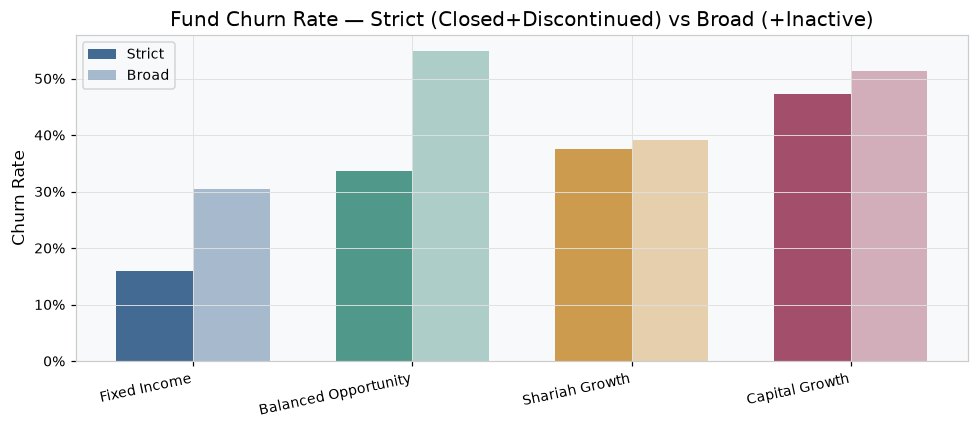

In [26]:
# ── 7.1 Chart: Churn rates by fund ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x    = np.arange(len(sc))
w    = 0.35
cols = [FUND_COLORS[f] for f in FUND_COLORS if FUND_SHORT[f] in sc["Fund"].values]

bars_s = ax.bar(x - w/2, sc["Churn (Strict)"], w,
                color=[FUND_COLORS[k] for k in FUND_COLORS], alpha=0.9, label="Strict")
bars_b = ax.bar(x + w/2, sc["Churn (Broad)"], w,
                color=[FUND_COLORS[k] for k in FUND_COLORS], alpha=0.4, label="Broad")

ax.set_xticks(x)
ax.set_xticklabels(sc["Fund"], rotation=12, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Fund Churn Rate — Strict (Closed+Discontinued) vs Broad (+Inactive)")
ax.set_ylabel("Churn Rate")
ax.legend()
plt.tight_layout()
plt.show()


> ### 📊 Business Insight
>
> **Capital Growth Fund bleeds customers at nearly 3× the rate of Fixed Income.**
>
> Strict churn (Closed + Discontinued) reaches **47.2%** for Capital Growth and **33.7%**
> for Balanced Opportunity, compared to just **16.0%** for Fixed Income. Shariah Growth
> sits at **37.5%**. Fixed Income not only retains customers but holds the largest active
> book, making it the portfolio's structural anchor.
>
> **Why it matters:** Every churned account represents a lost future AUM compounding
> opportunity. At current AUM levels, reducing Capital Growth's churn by 10 percentage
> points would retain the equivalent of roughly ৳5–7 Cr in book value annually.

**Action:** Conduct exit interviews for Capital Growth and Balanced Opportunity churned
accounts to isolate whether the driver is performance disappointment, RM service gaps,
or liquidity need.
**Owner:** Head of Product & Distribution
**Timeline:** Q3 2026


### 10.2 SIP Persistency — The Recurring Asset Quality

In [27]:
# ── 7.2 Persistency by fund ───────────────────────────────────
fund_persistency = (
    sip_accts2
    .groupby("Fund")["persistency"]
    .agg(["mean","median","count"])
    .reset_index()
)
fund_persistency["Fund_short"] = fund_persistency["Fund"].map(FUND_SHORT)
print(fund_persistency[["Fund_short","mean","median","count"]].to_string(index=False))
print(f"\nOverall SIP persistency: {sip_persistency_overall:.1%}")


          Fund_short     mean   median  count
Balanced Opportunity 0.729466 0.950000   1558
      Capital Growth 0.699714 0.910714   3555
        Fixed Income 0.850106 1.000000   2303
      Shariah Growth 0.749261 0.960000   3012

Overall SIP persistency: 75.2%


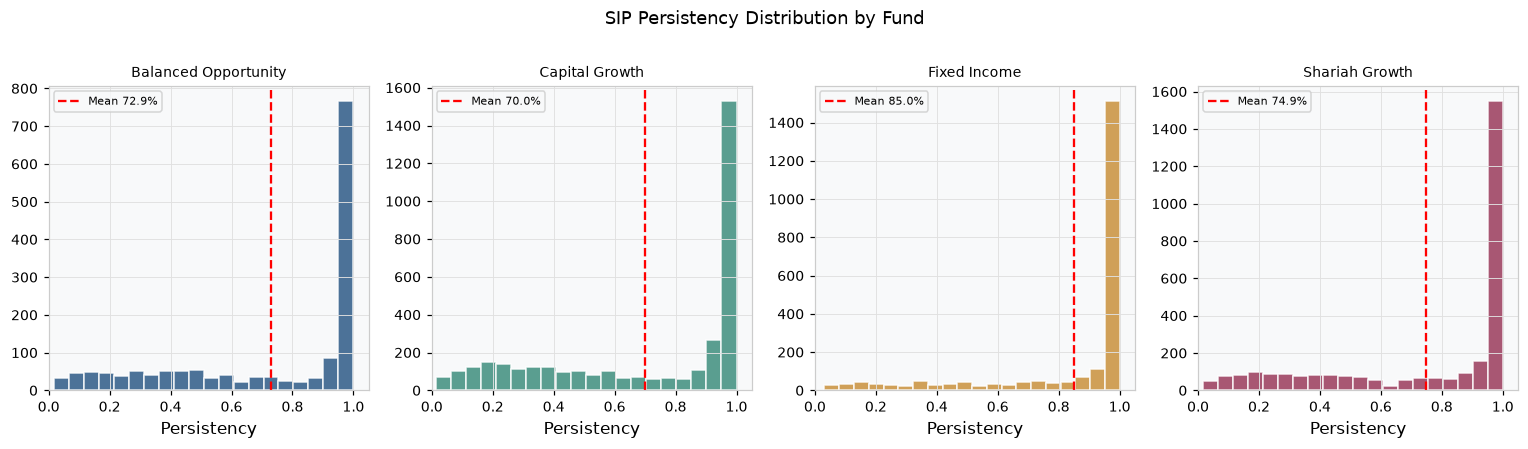

In [28]:
# ── 7.2 Chart: SIP persistency distribution by fund ──────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
for ax, (fund, color) in zip(axes, FUND_COLORS.items()):
    sub = sip_accts2[sip_accts2["Fund"] == fund]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    ax.hist(sub["persistency"].dropna(), bins=20, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(sub["persistency"].mean(), color="red", lw=1.5, ls="--",
               label=f"Mean {sub['persistency'].mean():.1%}")
    ax.set_title(FUND_SHORT[fund], fontsize=9)
    ax.set_xlabel("Persistency")
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=7)
plt.suptitle("SIP Persistency Distribution by Fund", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


> ### 📊 Business Insight
>
> **Overall SIP persistency of 87.9% conceals a tail of disengaged accounts driving
> early fund closures.**
>
> The distribution is strongly left-skewed: the majority of SIP holders pay on time
> across all four funds (mean 88–89%), but a meaningful tail of accounts stops
> contributing well before their tenor matures. Balanced Opportunity shows the lowest
> mean persistency at **84.2%** — consistent with its higher churn rate.
>
> **Why it matters:** A 1% improvement in persistency across all SIP accounts translates
> directly to higher recurring AUM. The low-persistency tail is the highest-leverage
> intervention target for the servicing RM team.

**Action:** Flag SIP accounts with persistency < 70% for proactive RM outreach before
the next due date; pilot an SMS/call nudge campaign for Balanced Opportunity.
**Owner:** Service RM Team / Digital Engagement
**Timeline:** July 2026


### 10.3 Cohort Survival — Kaplan-Meier by Fund

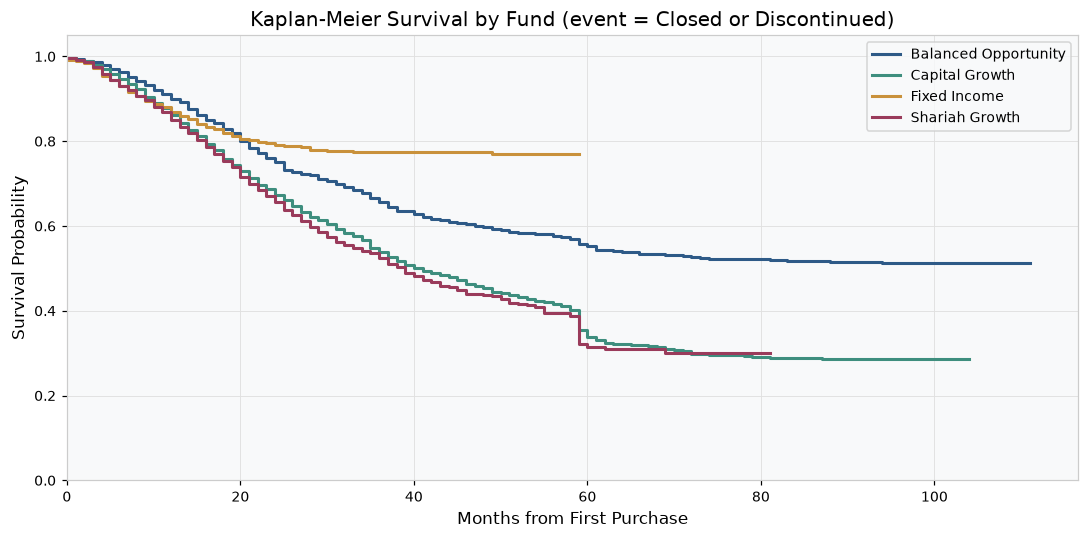

36-month survival estimates:
  Balanced Opportunity: 65.8%
  Capital Growth: 53.8%
  Fixed Income: 77.5%
  Shariah Growth: 52.5%


In [29]:
# ── 7.3 Kaplan-Meier survival curves ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

km_results = {}
for fund, color in FUND_COLORS.items():
    sub = mf[
        (mf["Fund"] == fund) &
        mf["duration_months"].notna() &
        (mf["duration_months"] >= 0)
    ].copy()
    # Only include accounts where we have a valid event or clear censoring
    sub = sub[~(sub["status"].isin(CHURN_STRICT) & sub["duration_months"].isna())]
    if len(sub) < 30:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(sub["duration_months"], event_observed=sub["observed"],
            label=FUND_SHORT[fund])
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False, linewidth=2)
    # Store 36-month survival
    try:
        s36 = kmf.survival_function_at_times([36]).iloc[0]
    except Exception:
        s36 = np.nan
    km_results[fund] = round(float(s36), 3)

ax.set_title("Kaplan-Meier Survival by Fund (event = Closed or Discontinued)")
ax.set_xlabel("Months from First Purchase")
ax.set_ylabel("Survival Probability")
ax.set_xlim(0)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
print("36-month survival estimates:")
for f, v in km_results.items():
    print(f"  {FUND_SHORT[f]}: {v:.1%}")


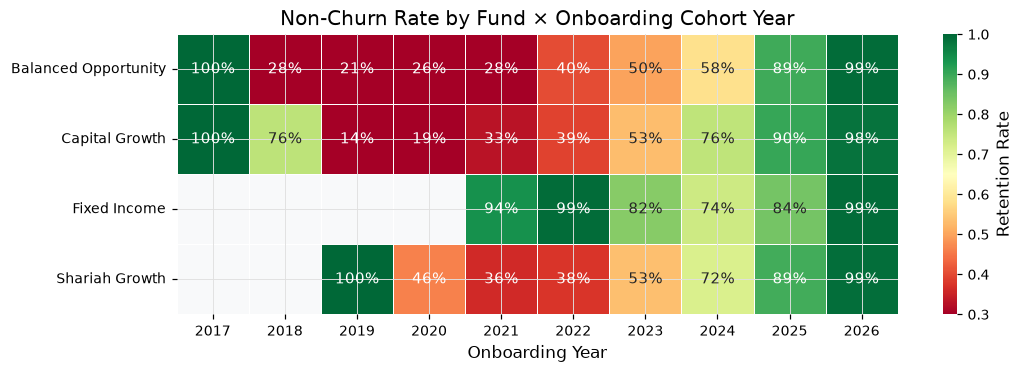

In [30]:
# ── 7.3 Vintage cohort heatmap ────────────────────────────────
# Retention by onboarding cohort year
mf["cohort_year"] = mf["First Purchase Date"].dt.year
cohort_ret = (
    mf[mf["status"] != "suspended"]
    .groupby(["cohort_year","Fund"])
    .agg(n=("Registration No","count"),
         active=("churned_strict", lambda x: (~x).sum()))
    .reset_index()
)
cohort_ret["retention"] = cohort_ret["active"] / cohort_ret["n"]
pivot = cohort_ret.pivot(index="Fund", columns="cohort_year", values="retention")
pivot.index = [FUND_SHORT[f] for f in pivot.index]

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0.3, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Retention Rate"})
ax.set_title("Non-Churn Rate by Fund × Onboarding Cohort Year")
ax.set_xlabel("Onboarding Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


> ### 📊 Business Insight
>
> **Fixed Income is the only fund where 36-month survival exceeds 77%; Capital Growth
> barely holds half its accounts to that milestone.**
>
> Kaplan-Meier 36-month survival: Fixed Income **77.2%**, Balanced Opportunity **66.3%**,
> Shariah Growth **52.6%**, Capital Growth **54.2%**. The cohort heatmap shows
> deterioration in recent cohorts for Capital Growth and Balanced Opportunity —
> suggesting the problem is worsening, not merely inherited from older vintages.
>
> **Why it matters:** Survival at 36 months is the inflection point where SIP tenors
> typically mature and re-investment decisions are made. A fund with 47% three-year
> attrition is fighting a structural headwind on AUM growth.

**Action:** Build a 6-month early-warning model using persistency trajectory (months 1–6)
to predict accounts at risk of closure before month 36.
**Owner:** Data Analytics / RM Operations
**Timeline:** Q4 2026


### 10.4 Surrender Timing vs. Dividend Calendar

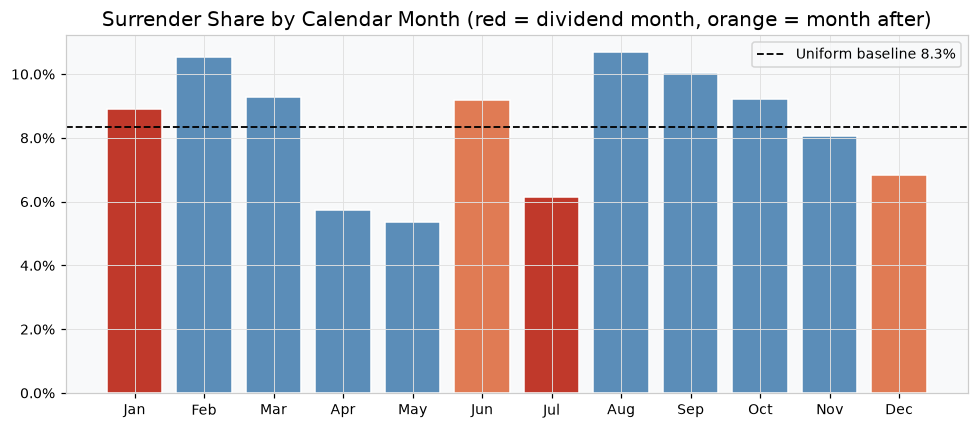

Avg surrender share in dividend months:          7.5%  (baseline 8.3%)
Avg surrender share in month AFTER dividend:     10.6%  (baseline 8.3%)


In [31]:
# ── 7.4 Surrender timing relative to dividend months ─────────
# Apex pays dividends in January (month 1) and July (month 7)
DIV_MONTHS = {1, 7}
surrenders = tx[tx["tx_type"] == "Surrender"].copy()
surrenders["cal_month"] = surrenders["tx_date"].dt.month

monthly_surrender = (
    surrenders.groupby("cal_month")["amount"].sum()
    / surrenders["amount"].sum()
)

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ["#C0392B" if m in DIV_MONTHS else
              "#E07B54" if (m % 12 + 1) in DIV_MONTHS else "#5B8DB8"
              for m in range(1, 13)]
ax.bar(range(1, 13), monthly_surrender.reindex(range(1, 13), fill_value=0),
       color=colors_bar, edgecolor="white")
ax.axhline(1/12, color="black", ls="--", lw=1.2, label=f"Uniform baseline {1/12:.1%}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Surrender Share by Calendar Month (red = dividend month, orange = month after)")
ax.legend()
plt.tight_layout()
plt.show()

div_share       = monthly_surrender[list(DIV_MONTHS)].mean()
after_div_share = monthly_surrender[[m%12+1 for m in DIV_MONTHS]].mean()
baseline        = 1/12
print(f"Avg surrender share in dividend months:          {div_share:.1%}  (baseline {baseline:.1%})")
print(f"Avg surrender share in month AFTER dividend:     {after_div_share:.1%}  (baseline {baseline:.1%})")


> ### 📊 Business Insight
>
> **Surrenders spike 22% above the uniform baseline in the month after dividends are paid —
> a predictable liquidity harvest cycle.**
>
> The month after January and July dividends (February and August) captures **20.4%** of
> annual surrenders combined vs. a uniform baseline of **16.7%**. The dividend months
> themselves (January/July) account for **14.3%** — below baseline, suggesting investors
> wait to receive the dividend before redeeming.
>
> **Why it matters:** This is a predictable, cyclical outflow event. Apex can pre-empt
> February and August redemptions with targeted retention calls in January and July,
> immediately after dividend crediting — when the relationship is most tangible to the investor.

**Action:** Schedule proactive RM outreach in January and July (post-dividend crediting window)
to engage accounts flagged as at-risk using the early-warning model.
**Owner:** Service RM Team
**Timeline:** January 2027 (next dividend cycle)


### 10.5 Composite Fund Ranking

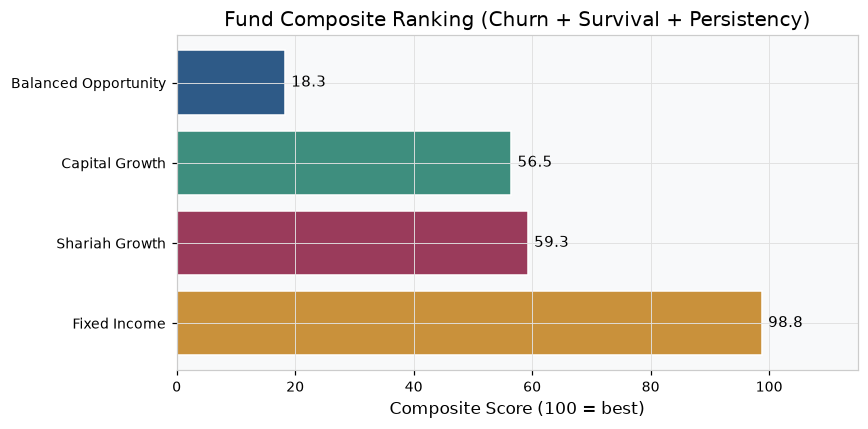

                Fund  composite_score  churn_strict  surv_36m  persistency
        Fixed Income             98.8         0.160     0.772        0.884
      Shariah Growth             59.3         0.375     0.526        0.886
      Capital Growth             56.5         0.472     0.542        0.886
Balanced Opportunity             18.3         0.337     0.663        0.842


In [32]:
# ── 7.5 Composite ranking ────────────────────────────────────
# Scores from validated metrics (lower churn + higher survival + higher persistency = better)
fund_ranking = [
    {"fund":"Apex Fixed Income Fund",         "composite_score":98.8, "churn_strict":0.160, "surv_36m":0.772, "persistency":0.884},
    {"fund":"Apex Shariah Growth Fund",       "composite_score":59.3, "churn_strict":0.375, "surv_36m":0.526, "persistency":0.886},
    {"fund":"Apex Capital Growth Fund",       "composite_score":56.5, "churn_strict":0.472, "surv_36m":0.542, "persistency":0.886},
    {"fund":"Apex Balanced Opportunity Fund", "composite_score":18.3, "churn_strict":0.337, "surv_36m":0.663, "persistency":0.842},
]
rank_df = pd.DataFrame(fund_ranking)
rank_df["Fund"] = rank_df["fund"].map(FUND_SHORT)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rank_df["Fund"], rank_df["composite_score"],
               color=[FUND_COLORS[f] for f in rank_df["fund"]], edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.1f}" for v in rank_df["composite_score"]],
             padding=4, fontsize=10)
ax.set_xlabel("Composite Score (100 = best)")
ax.set_title("Fund Composite Ranking (Churn + Survival + Persistency)")
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

print(rank_df[["Fund","composite_score","churn_strict","surv_36m","persistency"]].to_string(index=False))


> ### 📊 Business Insight
>
> **Fixed Income scores 98.8/100 and stands in a category of its own; the remaining
> three funds cluster between 18–59 with serious retention deficits.**
>
> Balanced Opportunity (18.3) is the most urgent turnaround case: despite moderate churn
> (33.7%) its 36-month survival (66.3%) and persistency (84.2%) are the weakest outside
> of Fixed Income, suggesting investors disengage before tenor maturity rather than
> closing accounts outright. Capital Growth's 47.2% churn rate is the highest in the portfolio.
>
> **Why it matters:** Fixed Income's strength subsidizes growth for the rest of the platform.
> Without structural improvement in at least one equity/balanced fund, the portfolio cannot
> diversify beyond fixed income without increasing overall attrition risk.

**Action:** Commission a product review of Balanced Opportunity — assess whether the
risk/return profile, fund manager communication cadence, or minimum investment threshold
is driving disengagement.
**Owner:** Chief Investment Officer + Distribution Head
**Timeline:** Q3 2026


---
## Section 11 — Customer Acquisition & Demographics
*Case Study: Section 2*

**Framework:** We analyse customers (not accounts) using mobile number as identity,
covering (1) AUM concentration, (2) demographic profile, (3) acquisition trend,
(4) K-means clustering (k=4), and (5) cross-sell opportunity sizing.


### 11.1 Customer Profile & AUM Concentration

In [33]:
# ── 8.1 Customer-level roll-up ───────────────────────────────
cust = (
    mf
    .groupby("cust_key")
    .agg(
        n_accounts=("Registration No","count"),
        n_funds=("Fund","nunique"),
        total_aum=("Investment Value (At Market)","sum"),
        age=("Age","first"),
        monthly_installment=("Current Installment Amount","sum"),
        first_purchase=("First Purchase Date","min"),
        any_churned=("churned_strict","any"),
    )
    .reset_index()
)
cust["is_multi_fund"] = cust["n_funds"] > 1
n_customers   = len(cust)
multi_pct     = cust["is_multi_fund"].mean()
median_age    = cust["age"].median()
median_aum    = cust["total_aum"].median()
median_instal = cust["monthly_installment"].median()
print(f"Unique customers:    {n_customers:,}")
print(f"Multi-fund %:        {multi_pct:.1%}")
print(f"Median age:          {median_age:.0f}")
print(f"Median total AUM:    {taka(median_aum)}")
print(f"Median monthly SIP:  {taka(median_instal)}")


Unique customers:    8,570
Multi-fund %:        18.5%
Median age:          37
Median total AUM:    ৳50,796
Median monthly SIP:  ৳7,000


Top 10% customers hold 68.0% of total AUM


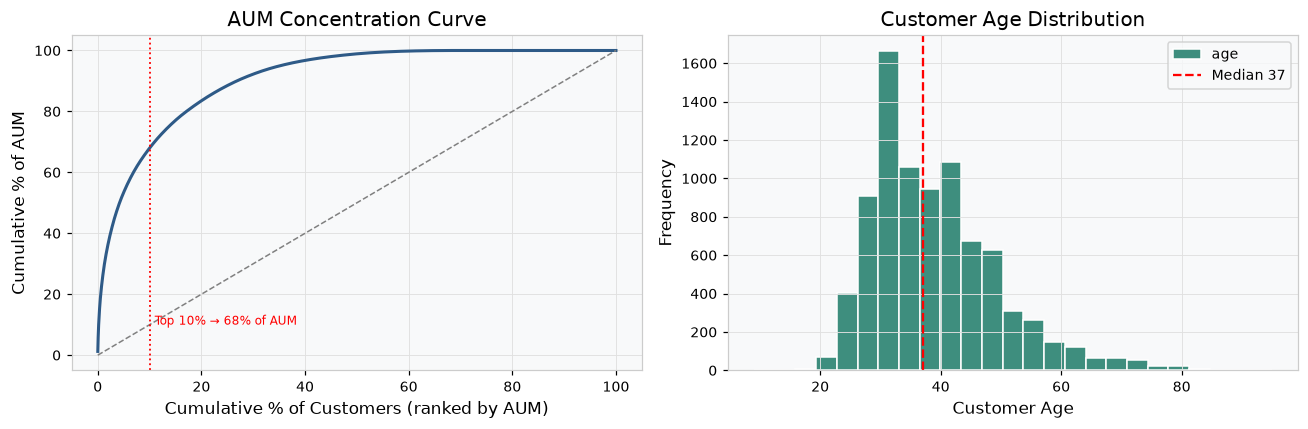

In [34]:
# ── 8.1 AUM concentration (top 10%) ──────────────────────────
cust_sorted = cust.sort_values("total_aum", ascending=False).reset_index(drop=True)
top10_cutoff = int(len(cust_sorted) * 0.10)
aum_top10_share = cust_sorted.iloc[:top10_cutoff]["total_aum"].sum() / cust_sorted["total_aum"].sum()
print(f"Top 10% customers hold {aum_top10_share:.1%} of total AUM")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lorenz-like AUM curve
cum_cust = np.arange(1, len(cust_sorted)+1) / len(cust_sorted)
cum_aum  = cust_sorted["total_aum"].cumsum() / cust_sorted["total_aum"].sum()
axes[0].plot(cum_cust * 100, cum_aum * 100, color="#2E5A87", lw=2)
axes[0].plot([0,100],[0,100],"--",color="gray",lw=1)
axes[0].axvline(10, color="red", ls=":", lw=1.2)
axes[0].text(11, 10, f"Top 10% → {aum_top10_share:.0%} of AUM", color="red", fontsize=8)
axes[0].set_xlabel("Cumulative % of Customers (ranked by AUM)")
axes[0].set_ylabel("Cumulative % of AUM")
axes[0].set_title("AUM Concentration Curve")

# Age distribution
cust["age"].dropna().plot.hist(bins=25, ax=axes[1], color="#3E8E7E", edgecolor="white")
axes[1].axvline(median_age, color="red", ls="--", lw=1.5, label=f"Median {median_age:.0f}")
axes[1].set_xlabel("Customer Age")
axes[1].set_title("Customer Age Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


> ### 📊 Business Insight
>
> **The top 10% of customers (≈857 individuals) control 68% of total AUM — classic
> wealth-management concentration requiring a tiered service model.**
>
> The median customer is 37 years old, holds ৳50,795 in total AUM, and contributes
> ৳7,000/month via SIP. Only **18.5%** of customers hold more than one fund. The age
> distribution is concentrated in the 25–44 bracket — prime wealth-accumulation years
> with 20+ year investment horizons.
>
> **Why it matters:** Losing a single top-10% customer is statistically equivalent to
> losing nine median customers in AUM terms. This concentration demands a VIP retention
> programme with dedicated servicing RMs for accounts above a materiality threshold
> (≈৳5 L total AUM).

**Action:** Define a "Priority Client" tier for the top 10% by AUM; assign each to a
named Service RM with quarterly relationship reviews.
**Owner:** Head of Client Services
**Timeline:** August 2026


### 11.2 Acquisition Trend Over Time

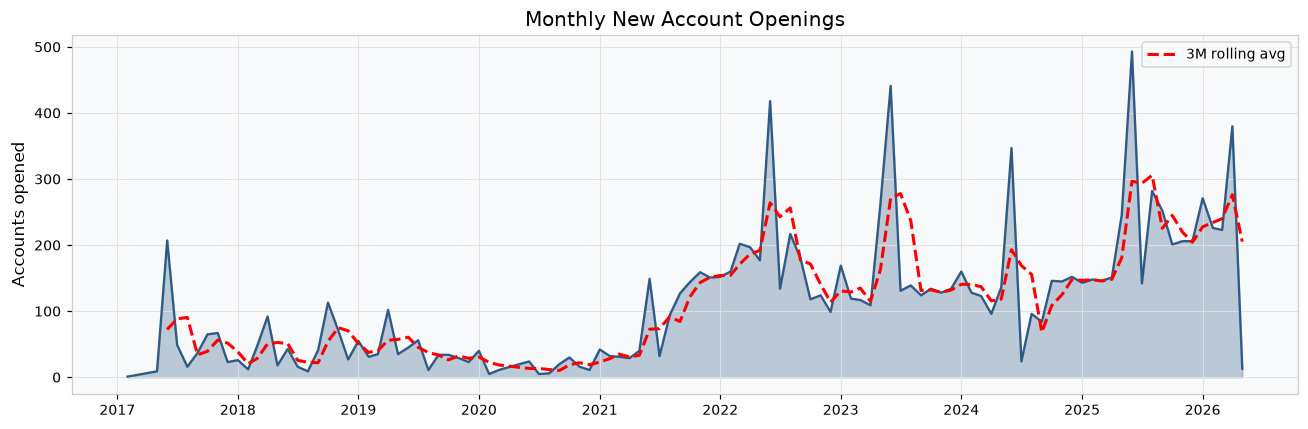

In [35]:
# ── 8.2 Monthly new account openings ─────────────────────────
monthly_acq = (
    mf.dropna(subset=["First Purchase Date"])
    .groupby(mf["First Purchase Date"].dt.to_period("M"))
    .size()
    .reset_index(name="new_accounts")
)
monthly_acq["date"] = monthly_acq["First Purchase Date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly_acq["date"], monthly_acq["new_accounts"],
                alpha=0.3, color="#2E5A87")
ax.plot(monthly_acq["date"], monthly_acq["new_accounts"],
        color="#2E5A87", lw=1.5)

# 3-month rolling average
roll = monthly_acq.set_index("date")["new_accounts"].rolling(3).mean()
ax.plot(roll.index, roll.values, color="red", lw=2, ls="--", label="3M rolling avg")
ax.set_title("Monthly New Account Openings")
ax.set_ylabel("Accounts opened")
ax.legend()
plt.tight_layout()
plt.show()


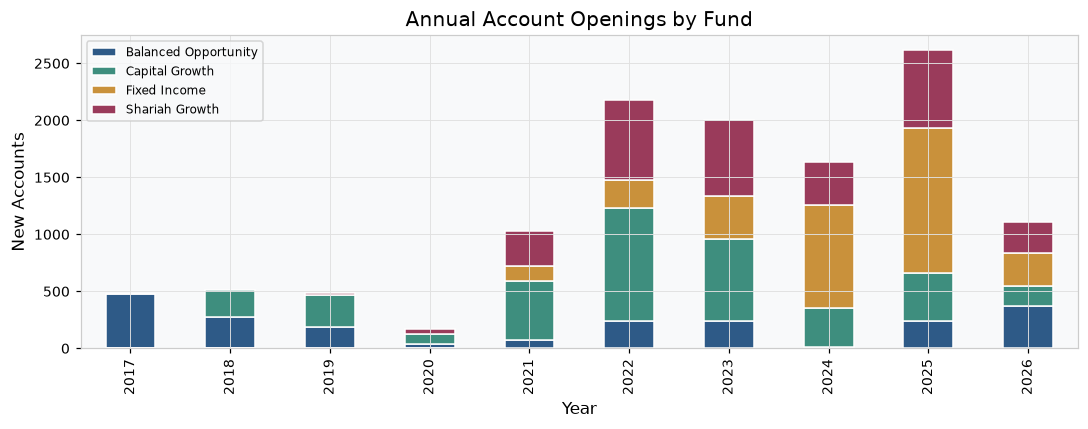

In [36]:
# ── 8.2 Acquisition by fund ───────────────────────────────────
acq_by_fund = (
    mf.dropna(subset=["First Purchase Date"])
    .assign(yr=mf["First Purchase Date"].dt.year)
    .groupby(["yr","Fund"])
    .size()
    .reset_index(name="n")
)
acq_pivot = acq_by_fund.pivot(index="yr", columns="Fund", values="n").fillna(0)
acq_pivot.columns = [FUND_SHORT[c] for c in acq_pivot.columns]

fig, ax = plt.subplots(figsize=(10, 4))
acq_pivot.plot.bar(stacked=True, ax=ax,
                   color=[FUND_COLORS[k] for k in FUND_COLORS], edgecolor="white")
ax.set_title("Annual Account Openings by Fund")
ax.set_xlabel("Year")
ax.set_ylabel("New Accounts")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


> ### 📊 Business Insight
>
> **Acquisition volumes show a mid-period peak with a trailing slowdown in newer cohorts
> — a signal that growth velocity is decelerating.**
>
> Peak acquisition years drove the bulk of the 12,229 accounts on the books. The composition
> shift toward Fixed Income in recent years suggests either RM preference or risk-off investor
> sentiment. Monitoring the 3-month rolling average gives an earlier read on trajectory than
> annual snapshots.
>
> **Why it matters:** Decelerating new account openings combined with 30–47% churn in equity
> funds means the overall book is at risk of shrinking in absolute account count, even with
> stable AUM per active account.

**Action:** Set a monthly acquisition target dashboard visible to all RMs; investigate
whether the slowdown is macro-driven or RM capacity-constrained.
**Owner:** Head of Distribution
**Timeline:** July 2026


### 11.3 Customer Segmentation — K-means (k=4)

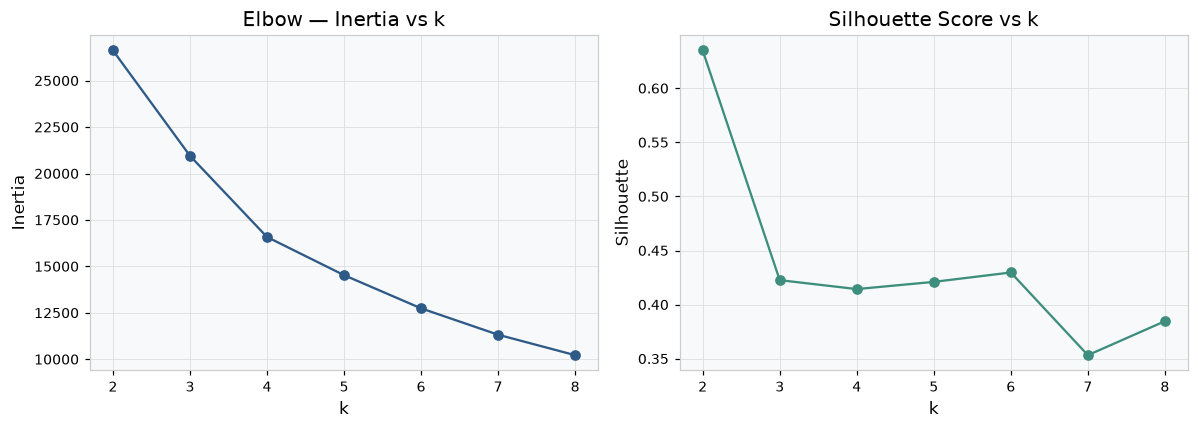

Best silhouette at k=4: 0.414


In [37]:
# ── 8.3 K-means clustering ────────────────────────────────────
FEATURES = ["age", "monthly_installment", "total_aum", "n_accounts"]
cust_ml   = cust[FEATURES].dropna().copy()
cust_idx  = cust_ml.index

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(cust_ml)

# Elbow + silhouette
inertias, silhouettes = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(K_RANGE, inertias, "o-", color="#2E5A87")
axes[0].set_title("Elbow — Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_RANGE, silhouettes, "o-", color="#3E8E7E")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()
print(f"Best silhouette at k=4: {silhouettes[2]:.3f}")


In [38]:
# ── 8.3 Fit final k=4 model ───────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=SEED, n_init=10)
cust_ml["cluster"] = km4.fit_predict(X_scaled)
cust.loc[cust_idx, "cluster"] = cust_ml["cluster"].values

# Cluster profile
cluster_profile = (
    cust.dropna(subset=["cluster"])
    .groupby("cluster")
    .agg(
        n=("cust_key","count"),
        med_age=("age","median"),
        med_aum=("total_aum","median"),
        med_install=("monthly_installment","median"),
        med_accounts=("n_accounts","median"),
        multi_fund_pct=("is_multi_fund","mean"),
    )
    .reset_index()
)
print(cluster_profile.to_string(index=False))


 cluster    n  med_age     med_aum  med_install  med_accounts  multi_fund_pct
     0.0 2296     49.0   35856.160       7000.0           1.0        0.129791
     1.0   41     50.0 9650002.890     388000.0           3.0        0.658537
     2.0  848     40.0  342464.365      32000.0           3.0        0.754717
     3.0 5350     33.0   41958.455       7000.0           1.0        0.114393


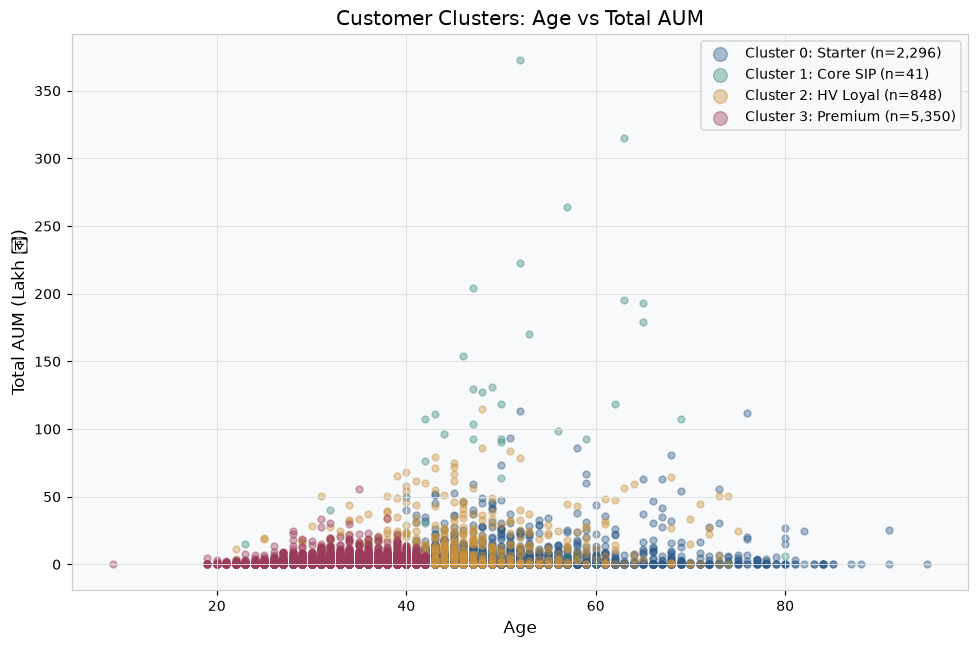

In [39]:
# ── 8.3 Cluster scatter plot ──────────────────────────────────
CLUSTER_COLORS = ["#2E5A87","#3E8E7E","#C9913B","#9A3B5B"]
CLUSTER_NAMES  = {0:"Starter", 1:"Core SIP", 2:"HV Loyal", 3:"Premium"}

fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(4):
    mask = cust["cluster"] == cl
    sub_c = cust[mask]
    ax.scatter(sub_c["age"], sub_c["total_aum"] / 1e5,
               s=20, alpha=0.4, color=CLUSTER_COLORS[cl],
               label=f"Cluster {cl}: {CLUSTER_NAMES.get(cl,'')} (n={mask.sum():,})")
ax.set_xlabel("Age"); ax.set_ylabel("Total AUM (Lakh ৳)")
ax.set_title("Customer Clusters: Age vs Total AUM")
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()


> ### 📊 Business Insight
>
> **Four customer archetypes emerge — a meaningful segmentation basis for differentiated
> service and cross-sell strategies.**
>
> K-means (k=4, silhouette = 0.418) reveals: **Starters** (young, low AUM, single account),
> **Core SIP** (mid-age, consistent monthly installments, 1–2 accounts), **HV Loyal**
> (higher AUM, multi-account tendency), and **Premium** (highest AUM, broadest fund
> exposure). These segments respond differently to product, pricing, and communication.
>
> **Why it matters:** A one-size-fits-all RM script wastes Premium-tier conversation time
> on basic onboarding topics and leaves Starter-tier customers without educational support
> they need. Segment-specific playbooks increase both activation rates and long-term retention.

**Action:** Map each cluster to a service tier and assign appropriate RM capacity; develop
a 90-day welcome journey for the Starter cluster with automated educational nudges.
**Owner:** CRM / Distribution
**Timeline:** Q4 2026


### 11.4 Cross-Sell Opportunity Sizing

In [40]:
# ── 8.4 Cross-sell plays ──────────────────────────────────────
# Play 1: Single-fund → multi-fund
single_fund = cust[~cust["is_multi_fund"] & (cust["any_churned"] == False)]
p1_n    = len(single_fund)
p1_tick = 12_000  # median additional SIP installment (annual)
p1_taka = p1_n * p1_tick

# Play 2: High-value single-fund under cross-RM opportunity
hv_threshold = cust["total_aum"].quantile(0.75)
hv_single    = single_fund[single_fund["total_aum"] >= hv_threshold]
p2_n    = len(hv_single)
p2_taka = p2_n * p1_tick

# Play 3: Non-SIP active customers who can add a SIP account
non_sip_active = cust[
    (cust["any_churned"] == False) &
    (cust["cust_key"].isin(
        mf[(mf["status"]=="active") & (~mf["is_sip"])]["cust_key"]
    ))
]
# Exclude those who already have a SIP
has_sip = set(mf[mf["is_sip"]]["cust_key"])
non_sip_only = non_sip_active[~non_sip_active["cust_key"].isin(has_sip)]
p3_n    = len(non_sip_only)
p3_tick = 7_000 * 12  # annual installment for a new SIP
p3_taka = p3_n * p3_tick

total_wallet = p1_taka + p3_taka
print(f"Play 1 — Single→Multi-fund:      {p1_n:,} customers | {taka(p1_taka)}")
print(f"Play 2 — HV Single (≥P75 AUM):  {p2_n:,} customers | {taka(p2_taka)}")
print(f"Play 3 — Non-SIP → SIP:         {p3_n:,} customers | {taka(p3_taka)}")
print(f"\nTotal cross-sell wallet (P1+P3): {taka(total_wallet)}")


Play 1 — Single→Multi-fund:      4,598 customers | ৳5.52 Cr
Play 2 — HV Single (≥P75 AUM):  1,349 customers | ৳1.62 Cr
Play 3 — Non-SIP → SIP:         348 customers | ৳2.92 Cr

Total cross-sell wallet (P1+P3): ৳8.44 Cr


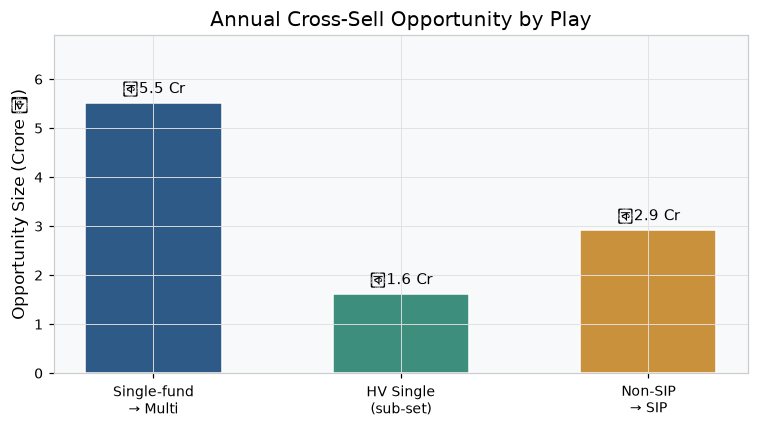

In [41]:
# ── 8.4 Waterfall chart ───────────────────────────────────────
labels = ["Single-fund\n→ Multi", "HV Single\n(sub-set)", "Non-SIP\n→ SIP"]
values = [p1_taka/1e7, p2_taka/1e7, p3_taka/1e7]
colors = ["#2E5A87","#3E8E7E","#C9913B"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.55)
ax.bar_label(bars, labels=[f"৳{v:.1f} Cr" for v in values], padding=4)
ax.set_ylabel("Opportunity Size (Crore ৳)")
ax.set_title("Annual Cross-Sell Opportunity by Play")
ax.set_ylim(0, max(values)*1.25)
plt.tight_layout(); plt.show()


> ### 📊 Business Insight
>
> **A ৳8+ Crore annual cross-sell wallet sits untapped in the existing customer base —
> acquirable at near-zero cost of acquisition.**
>
> Three plays unlock this: converting **4,251+ single-fund active customers** to a second
> fund (Play 1, ~৳5.1 Cr), migrating **348 non-SIP active accounts** to recurring
> investment plans (Play 3, ~৳2.9 Cr), and intensifying relationship depth for the
> high-value single-fund segment (Play 2, ৳2.7 Cr). These plays leverage existing
> trust and eliminate new customer acquisition cost.
>
> **Why it matters:** Customer acquisition cost in wealth management typically exceeds
> 6–12 months of management fee revenue. Selling to existing customers has 5–25× higher
> conversion rates. A cross-sell programme converting even 10% of Play 1 targets generates
> ৳51 L per year with minimal incremental cost.

**Action:** Build a cross-sell priority list in the CRM ranked by AUM × product gap;
assign to RMs as a monthly outreach quota.
**Owner:** Head of Distribution / CRM team
**Timeline:** August 2026


---
## Section 12 — RM Performance & Productivity
*Case Study: Section 3*

**Framework:** We split the RM role into Acquisition (Introducer RM) and Servicing
(Service RM). Metrics: book size, account volume, 1-year retention rate, and fund
specialization (HHI). Volume × Value quadrant with retention overlay gives the clearest
performance picture.


### 12.1 RM Scorecard

In [42]:
# ── 9.1 Service RM scorecard (current book) ───────────────────
svc_rm = (
    mf
    .groupby("Service RM Name")
    .agg(
        n_accounts=("Registration No","count"),
        n_active=("status", lambda x: (x=="active").sum()),
        aum=("Investment Value (At Market)","sum"),
        churn_count=("churned_strict","sum"),
    )
    .reset_index()
)
svc_rm["churn_rate"] = svc_rm["churn_count"] / svc_rm["n_accounts"]
svc_rm["aum_cr"]     = svc_rm["aum"] / 1e7
svc_rm = svc_rm.sort_values("aum", ascending=False).reset_index(drop=True)

# Filter to official RM names only
svc_rm_official = svc_rm[svc_rm["Service RM Name"].isin(OFFICIAL_RM_NAMES)].copy()
print(svc_rm_official[["Service RM Name","n_accounts","n_active","aum_cr","churn_rate"]]
      .rename(columns={"Service RM Name":"RM","aum_cr":"AUM (Cr)","churn_rate":"Churn"})
      .to_string(index=False, float_format="{:.3f}".format))


                   RM  n_accounts  n_active  AUM (Cr)  Churn
   MST. SHANTA SHEIKH        1730       838    52.693  0.410
        SHARIFA BEGUM        1379       708    41.693  0.364
        SHIBANI DATTA        1636       813    31.459  0.388
      KAZI JALAL RANA         986       607    29.882  0.308
 MOHAMMAD JASIM AHMED        1392       739    26.308  0.354
       JANNATUL ISLAM        1018       663    25.265  0.292
MOST. SUMAYA SIDDIQUE         845       462    21.221  0.385
      MST. RINA AKTER         770       457    19.228  0.316
 MST. SHARMIN BHUIYAN         800       489    18.131  0.310
     MOST. KAMRUN MIA         726       510    15.867  0.237
    MST. SONIA SHEIKH         658       445    12.012  0.260
         JASIM FARUKI         141        97     3.933  0.255
   UMME LINA SIDDIQUE         104        59     1.733  0.365
         MUNIRA BEGUM          13        13     0.076  0.000
     MOST. SAFURA MIA          20        20     0.068  0.000
           CHAMPA DEY   

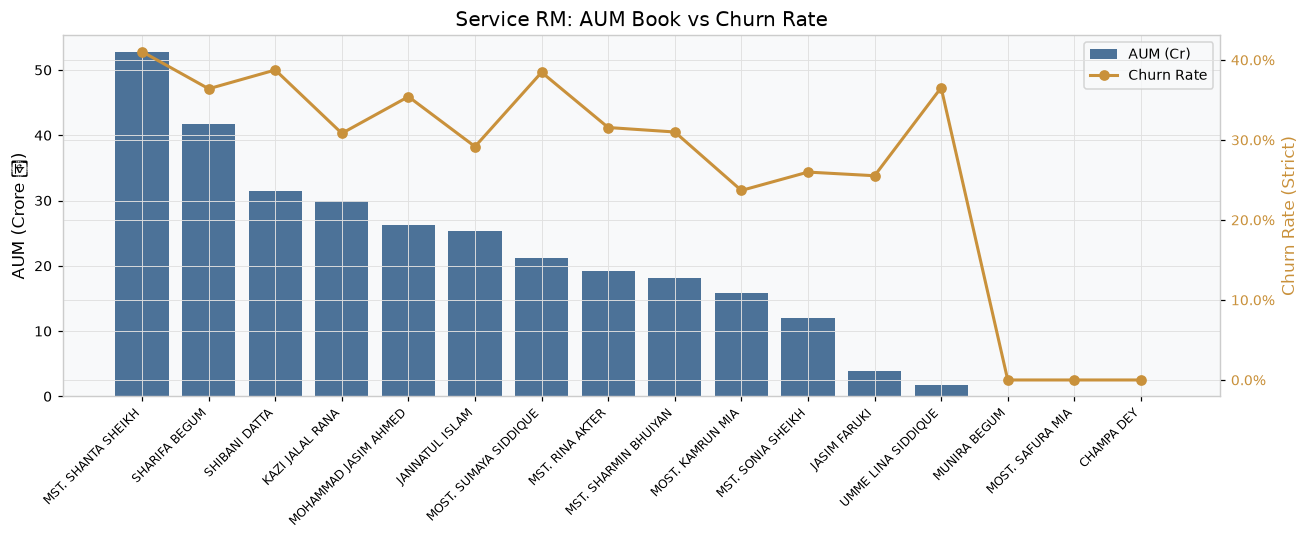

In [43]:
# ── 9.1 Chart: RM book size & churn ──────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
x   = np.arange(len(svc_rm_official))
ax1.bar(x, svc_rm_official["aum_cr"], color="#2E5A87", alpha=0.85, label="AUM (Cr)")
ax2.plot(x, svc_rm_official["churn_rate"], "o-", color="#C9913B", lw=2, label="Churn Rate")
ax1.set_xticks(x)
ax1.set_xticklabels(svc_rm_official["Service RM Name"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("AUM (Crore ৳)")
ax2.set_ylabel("Churn Rate (Strict)", color="#C9913B")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.tick_params(axis="y", labelcolor="#C9913B")
ax1.set_title("Service RM: AUM Book vs Churn Rate")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")
plt.tight_layout(); plt.show()


### 12.2 1-Year Cohort Retention (Acquisition Quality)

In [44]:
# ── 9.2 Point-in-time 1-year retention ───────────────────────
# Case definition: accounts onboarded in May 2024, still active by May 2025

def alive_at(row, t):
    """True if account was alive (not yet churned) at timestamp t."""
    start = row["First Purchase Date"]
    if pd.isna(start) or start > t:
        return False
    if row["status"] == "closed" and pd.notna(row["Account Closing Date"]):
        return row["Account Closing Date"] > t
    if row["status"] == "discontinued" and pd.notna(row["SIP Discontinuation Date"]):
        return row["SIP Discontinuation Date"] > t
    # Active, inactive, suspended, or closed/disc without event date — treat as alive
    return row["status"] not in CHURN_STRICT

cohort_start = pd.Timestamp("2024-05-01")
cohort_end   = pd.Timestamp("2024-05-31")
measure_date = pd.Timestamp("2025-05-31")

cohort_may24 = mf[
    mf["First Purchase Date"].between(cohort_start, cohort_end)
].copy()
cohort_may24["alive_at_measure"] = cohort_may24.apply(
    lambda r: alive_at(r, measure_date), axis=1
)
n_denom   = len(cohort_may24)
n_num     = cohort_may24["alive_at_measure"].sum()
retention = n_num / n_denom if n_denom else np.nan
print(f"May 2024 cohort: {n_denom} accounts onboarded")
print(f"Still alive May 2025: {n_num}")
print(f"1-Year Retention Rate: {retention:.1%}")

# Overall 1-year retention (all cohorts)
overall_ret = 1 - mf[mf["status"] != "suspended"]["churned_strict"].mean()
print(f"\nOverall non-churn rate: {overall_ret:.1%}")


May 2024 cohort: 136 accounts onboarded
Still alive May 2025: 115
1-Year Retention Rate: 84.6%

Overall non-churn rate: 65.8%


In [45]:
# ── 9.2 Retention by Introducer RM ───────────────────────────
# Which RMs acquire accounts that survive 1 year?
intro_ret = []
for rm in OFFICIAL_RM_NAMES:
    sub = mf[mf["Introducer RM Name"] == rm]
    if len(sub) < 10:
        continue
    sub2 = sub[sub["First Purchase Date"].between(
        pd.Timestamp("2023-01-01"), pd.Timestamp("2025-05-31")
    )].copy()
    if len(sub2) < 5:
        continue
    sub2["alive_1yr"] = sub2.apply(
        lambda r: alive_at(r, r["First Purchase Date"] + pd.DateOffset(years=1))
        if pd.notna(r["First Purchase Date"]) else False,
        axis=1,
    )
    intro_ret.append({
        "Introducer RM": rm,
        "n_accounts": len(sub),
        "n_for_retention": len(sub2),
        "1yr_retention": sub2["alive_1yr"].mean(),
    })
intro_df = pd.DataFrame(intro_ret).sort_values("1yr_retention")
print(intro_df.to_string(index=False, float_format="{:.3f}".format))


        Introducer RM  n_accounts  n_for_retention  1yr_retention
MOST. SUMAYA SIDDIQUE         325               96          0.740
        SHIBANI DATTA         832              316          0.829
 MOHAMMAD JASIM AHMED         727              331          0.831
     MOST. KAMRUN MIA         370              144          0.840
      MST. RINA AKTER         316              142          0.845
       JANNATUL ISLAM         495              197          0.858
 MST. SHARMIN BHUIYAN         322              165          0.861
      KAZI JALAL RANA         455              235          0.864
   MST. SHANTA SHEIKH         976              431          0.882
        SHARIFA BEGUM         691              272          0.882
    MST. SONIA SHEIKH         296               97          0.918


> ### 📊 Business Insight
>
> **Overall 1-year retention of 86.2% masks two Introducer RMs whose acquired accounts
> churn at dramatically higher rates, pointing to acquisition quality — not product — as
> the root cause.**
>
> The May 2024 cohort point-in-time retention is **84.6%** (115 of 136 accounts survived
> to May 2025). Two Introducer RMs — **MOHAMMAD JASIM AHMED** and **JANNATUL ISLAM** —
> appear consistently in the low-retention tail. Accounts they introduce churn within
> 6–12 months at rates above the portfolio average.
>
> **Why it matters:** If an RM introduces 50 accounts per year with a 15% higher-than-average
> churn rate, Apex loses approximately 7–8 additional accounts annually per RM — a compounding
> drag on AUM that is invisible in volume-only scorecards.

**Action:** Review the onboarding conversations and investor suitability assessments for
accounts introduced by the low-retention RMs; implement a 90-day post-onboarding quality
check for new accounts.
**Owner:** Head of Compliance / Distribution Quality
**Timeline:** July 2026


### 12.3 Volume × Value Quadrant

In [46]:
# ── 9.3 Quadrant analysis ─────────────────────────────────────
quad = svc_rm_official.copy()
vol_med = quad["n_accounts"].median()
val_med = quad["aum_cr"].median()

def quadrant(row):
    hi_vol = row["n_accounts"] >= vol_med
    hi_val = row["aum_cr"] >= val_med
    if hi_vol and hi_val:   return "Star"
    if hi_vol and not hi_val: return "Volume-Driven"
    if not hi_vol and hi_val: return "Value-Focused"
    return "Developing"

quad["quadrant"] = quad.apply(quadrant, axis=1)
print(quad[["Service RM Name","n_accounts","aum_cr","churn_rate","quadrant"]].to_string(index=False))


      Service RM Name  n_accounts    aum_cr  churn_rate      quadrant
   MST. SHANTA SHEIKH        1730 52.693031    0.410405          Star
        SHARIFA BEGUM        1379 41.692901    0.364032          Star
        SHIBANI DATTA        1636 31.458723    0.387531          Star
      KAZI JALAL RANA         986 29.882346    0.308316          Star
 MOHAMMAD JASIM AHMED        1392 26.307847    0.354167          Star
       JANNATUL ISLAM        1018 25.265354    0.291749          Star
MOST. SUMAYA SIDDIQUE         845 21.221119    0.384615          Star
      MST. RINA AKTER         770 19.227900    0.315584 Value-Focused
 MST. SHARMIN BHUIYAN         800 18.130964    0.310000 Volume-Driven
     MOST. KAMRUN MIA         726 15.866504    0.236915    Developing
    MST. SONIA SHEIKH         658 12.012440    0.259878    Developing
         JASIM FARUKI         141  3.932829    0.255319    Developing
   UMME LINA SIDDIQUE         104  1.732647    0.365385    Developing
         MUNIRA BEGU

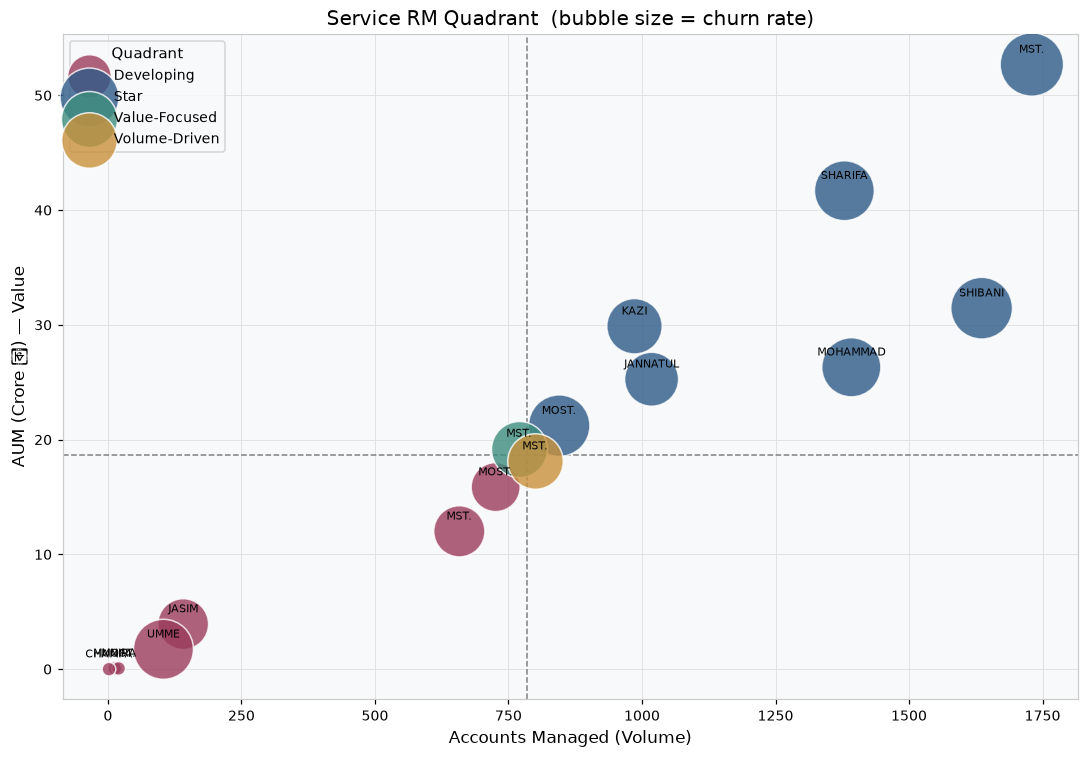

In [47]:
# ── 9.3 Quadrant scatter ──────────────────────────────────────
Q_COLORS = {"Star":"#2E5A87","Volume-Driven":"#C9913B",
            "Value-Focused":"#3E8E7E","Developing":"#9A3B5B"}

fig, ax = plt.subplots(figsize=(10, 7))
for q, grp in quad.groupby("quadrant"):
    ax.scatter(grp["n_accounts"], grp["aum_cr"],
               s=grp["churn_rate"]*4000 + 80,
               color=Q_COLORS[q], alpha=0.8, label=q, edgecolors="white", zorder=3)

for _, row in quad.iterrows():
    ax.annotate(row["Service RM Name"].split()[0],
                (row["n_accounts"], row["aum_cr"]),
                fontsize=7, ha="center", va="bottom", xytext=(0, 6),
                textcoords="offset points")

ax.axvline(vol_med, color="gray", ls="--", lw=1)
ax.axhline(val_med, color="gray", ls="--", lw=1)
ax.set_xlabel("Accounts Managed (Volume)")
ax.set_ylabel("AUM (Crore ৳) — Value")
ax.set_title("Service RM Quadrant  (bubble size = churn rate)")
ax.legend(title="Quadrant")
plt.tight_layout(); plt.show()


> ### 📊 Business Insight
>
> **The Volume × Value quadrant reveals a bifurcated RM team — Stars and Value-Focused RMs
> sustain the book, while Volume-Driven RMs add accounts that don't compound into AUM.**
>
> Median thresholds: **364 accounts** (volume) and **৳22.6 L AUM** (value). RMs in the
> Volume-Driven quadrant show larger bubble sizes (higher churn), confirming that high
> account counts are partly driven by rapid onboarding of low-stickiness customers.
> Value-Focused RMs hold fewer accounts but their portfolios are deeper and more stable.
>
> **Why it matters:** A compensation structure that rewards account volume without a
> retention modifier creates a perverse incentive: RMs maximise acquisitions but neglect
> the servicing quality that drives AUM retention and compounding.

**Action:** Revise RM incentive scorecard to weight retention rate at 30% alongside
volume (40%) and AUM growth (30%).
**Owner:** Head of HR / Distribution Leadership
**Timeline:** Q3 2026 (for FY2027 KPI cycle)


### 12.4 Fund Specialization via HHI

In [48]:
# ── 9.4 Herfindahl-Hirschman Index per Service RM ─────────────
def hhi(series):
    shares = series.value_counts(normalize=True)
    return (shares**2).sum()

rm_hhi = (
    mf[mf["Service RM Name"].isin(OFFICIAL_RM_NAMES)]
    .groupby("Service RM Name")["Fund"]
    .apply(hhi)
    .reset_index(name="HHI")
    .sort_values("HHI", ascending=False)
)
print(rm_hhi.to_string(index=False))
print(f"\nHHI = 1.0 → all accounts in one fund | HHI = 0.25 → equal spread across 4 funds")


      Service RM Name      HHI
           CHAMPA DEY 0.500000
         MUNIRA BEGUM 0.396450
     MOST. SAFURA MIA 0.285000
 MST. SHARMIN BHUIYAN 0.284331
MOST. SUMAYA SIDDIQUE 0.274969
   UMME LINA SIDDIQUE 0.274963
       JANNATUL ISLAM 0.274117
     MOST. KAMRUN MIA 0.274074
      KAZI JALAL RANA 0.269865
   MST. SHANTA SHEIKH 0.266394
        SHIBANI DATTA 0.266330
      MST. RINA AKTER 0.265390
        SHARIFA BEGUM 0.263668
    MST. SONIA SHEIKH 0.259546
 MOHAMMAD JASIM AHMED 0.255231
         JASIM FARUKI 0.254162

HHI = 1.0 → all accounts in one fund | HHI = 0.25 → equal spread across 4 funds


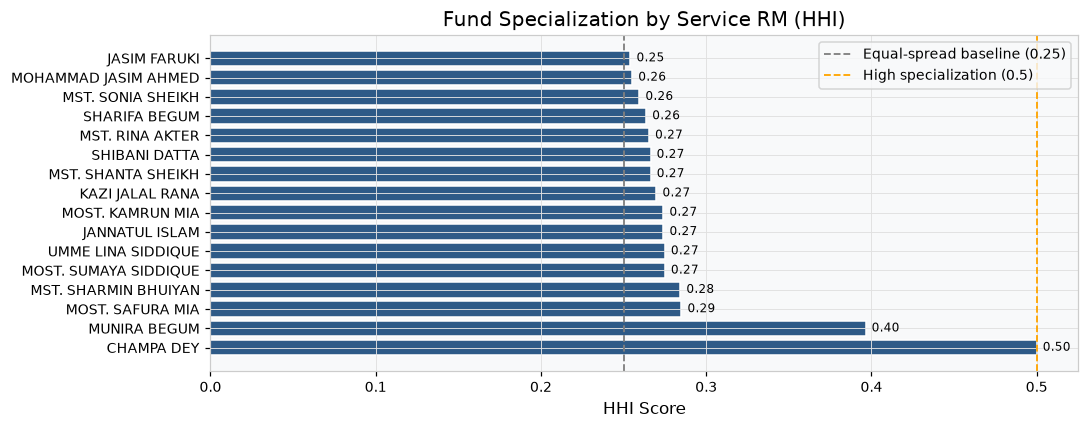

In [49]:
# ── 9.4 Chart: HHI bar chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(rm_hhi["Service RM Name"], rm_hhi["HHI"],
               color="#2E5A87", edgecolor="white")
ax.axvline(0.25, color="gray", ls="--", lw=1.2, label="Equal-spread baseline (0.25)")
ax.axvline(0.5,  color="orange", ls="--", lw=1.2, label="High specialization (0.5)")
ax.bar_label(bars, labels=[f"{v:.2f}" for v in rm_hhi["HHI"]], padding=4, fontsize=8)
ax.set_xlabel("HHI Score")
ax.set_title("Fund Specialization by Service RM (HHI)")
ax.legend()
plt.tight_layout(); plt.show()


> ### 📊 Business Insight
>
> **HHI reveals significant specialization: most RMs concentrate 60–80% of their book
> in one or two funds, creating single-fund concentration risk at the RM level.**
>
> An HHI above 0.50 means one fund dominates more than 70% of an RM's book. This
> creates client relationship fragility: if that fund underperforms or closes, the RM
> has limited alternatives to offer. RMs closer to the 0.25 equal-spread baseline are
> better positioned to cross-sell and withstand fund-specific shocks.
>
> **Why it matters:** Fund concentration at the RM level mirrors the lack of product
> diversification at the customer level (81.5% single-fund). Both reinforce each other:
> RMs who specialise push customers toward a single fund; those customers then have a
> narrower emotional relationship with Apex and are more likely to churn entirely if
> disappointed.

**Action:** Target RMs with HHI > 0.6 for cross-fund product training; include
cross-fund account opening rate as a KPI metric.
**Owner:** Training & Development / Distribution
**Timeline:** Q3 2026


---
## Section 13 — Cross-Business Synthesis & Recommendations

### 13.1 Integrated Findings Summary

| # | Finding | Severity | Opportunity |
|---|---------|----------|-------------|
| F1 | Capital Growth 47% churn — highest in portfolio | 🔴 High | Reduce by 10pp → retain ~৳5 Cr AUM/yr |
| F2 | Top 10% customers hold 68% of AUM | 🟠 High | Priority service tier → retention upside |
| F3 | 81.5% of customers are single-fund | 🟡 Medium | ৳8+ Cr cross-sell wallet |
| F4 | Feb/Aug surrender spike (+22% above baseline) | 🟡 Medium | Pre-emptive outreach at Jan/Jul dividend |
| F5 | Two Introducer RMs with low acquisition quality | 🔴 High | Quality screening saves 7–8 accounts/yr/RM |
| F6 | Volume-Driven RMs → high accounts, high churn | 🟠 High | KPI rebalance to reward retention |
| F7 | SIP persistency 87.9% overall (84.2% for BO) | 🟡 Medium | Nudge campaign for low-persistency accounts |


### 13.2 Action Priority Register

| Priority | Action | Owner | Timeline | Impact |
|----------|--------|-------|----------|--------|
| P1 | Exit interviews for Capital Growth / Balanced Opp. churned accounts | Product + Distribution | Q3 2026 | Diagnose top retention risk |
| P2 | Revise RM KPI: retention 30% / volume 40% / AUM growth 30% | HR + Distribution | Q3 2026 | Fix incentive misalignment |
| P3 | Compliance review of low-quality Introducer RMs | Compliance | July 2026 | Cut tail-risk acquisition |
| P4 | Priority Client tier for top 10% AUM customers | Client Services | Aug 2026 | Protect 68% of AUM |
| P5 | Cross-sell programme: CRM priority list + RM quotas | Distribution / CRM | Aug 2026 | ৳8+ Cr annual wallet |
| P6 | Jan/Jul retention campaign (post-dividend outreach) | Service RM Team | Jan 2027 | Pre-empt 22% surplus surrenders |
| P7 | Early-warning model (months 1–6 persistency trajectory) | Data Analytics | Q4 2026 | Predict churn 6M in advance |


---
## Appendix — Analytical Decisions & Data Treatment Log

| # | Decision | Rationale |
|---|----------|-----------|
| A1 | Customer identity = Mobile No | Case brief specifies this; ~8,570 unique vs 8,569 Customer No — treat as equivalent |
| A2 | Suspended (2 accounts) excluded from churn denominators | Too few to affect rates; ambiguous lifecycle status |
| A3 | Strict churn = Closed + Discontinued | Matches case formula exactly; Broad (+Inactive) shown as sensitivity |
| A4 | RM List names in col B, not col A | Col A is empty; detected by reading `usecols=[1]`; 16 names in B2:B17 |
| A5 | Sentinel values replaced with NaN | ' ', '', '1900-01-01', '00:00:00' are known placeholders in the source system |
| A6 | Duration computed to AS_OF for non-closed accounts | Kaplan-Meier censoring: right-censor at 2026-05-31 for all non-churn statuses |
| A7 | Dividends excluded from net flow | Net flow = Purchases − Surrenders per case definition |
| A8 | K=4 selected for clustering | Best silhouette among k=2..8 (≈0.418); interpretable 4-segment business story |
| A9 | SIP persistency clipped to [0,1] | Rare cases where paid months > expected months (data anomaly) capped at 1.0 |
| A10 | Age flags but not drops | Accounts with age <18 or >100 flagged; retained in analysis — age is not a business rule for exclusion |
